# Скользящий контроль: сравнение методов оценки риска

---

## 1. Постановка задачи

Пусть дана выборка $X^n = \{(x_i, y_i)\}_{i=1}^{n}$, где $x_i \in \mathbb{R}^d$ — признаковое описание объекта, $y_i$ — целевая переменная. Требуется оценить **риск** (ошибку обобщения) алгоритма обучения $a$:

$$R(a) = \mathbb{E}_{(x,y)}\bigl[L\bigl(a(X^n),\, x,\, y\bigr)\bigr]$$

где $L$ — функция потерь. Прямая оценка на обучающей выборке смещена вниз из-за переобучения, поэтому используется **скользящий контроль** (cross-validation) — модель обучается на одной части данных, а проверяется на другой.

---

## 2. Методы скользящего контроля

### 2.1 Полный скользящий контроль (эталон)

**Определение.** Перебираются все возможные подмножества размера $m$ в качестве контрольной выборки.

$$\hat{R}_{\text{full}} = \frac{1}{\binom{n}{m}} \sum_{\substack{T \subseteq \{1,\ldots,n\} \\ |T| = m}} \frac{1}{m} \sum_{i \in T} L\bigl(a(X^n \setminus T),\; x_i,\; y_i\bigr)$$

**Свойства.** Наиболее точная оценка (минимальное смещение), вычислительно неподъёмна при больших $n$. Используется как **эталон** для сравнения остальных методов.

---

### 2.2 LOO — Leave-One-Out

**Определение.** Каждый объект по одному разу выступает контрольным:

$$\hat{R}_{\text{LOO}} = \frac{1}{n} \sum_{i=1}^{n} L\bigl(a(X^n \setminus \{x_i\}),\; x_i,\; y_i\bigr)$$

**Свойства.** Частный случай полного СК при $m = 1$. Число итераций: $n$. Оценка почти несмещённая, но обладает высокой дисперсией.

---

### 2.3 $t \times q$-блочный скользящий контроль

**Определение.** Выборка делится на $q$ равных блоков; каждый блок по очереди служит контрольным, остальные $q-1$ — обучающими. Процедура повторяется $t$ раз с независимыми случайными перемешиваниями:

$$\hat{R}_{t \times q} = \frac{1}{t} \sum_{r=1}^{t} \frac{1}{q} \sum_{k=1}^{q} \frac{1}{|B_k^{(r)}|} \sum_{i \in B_k^{(r)}} L\bigl(a(X^n \setminus B_k^{(r)}),\; x_i,\; y_i\bigr)$$

где $B_k^{(r)}$ — $k$-й блок в $r$-м перемешивании. Число итераций: $t \cdot q$.

**Частные случаи:** $q = n$ — LOO; $q = 2$ — hold-out; $q = 5, 10$ — стандартный $k$-fold.

---

### 2.4 СК по случайным подвыборкам (Random Subsampling)

**Определение.** На каждой из $t$ итераций случайно (без возвращения) выбирается контрольная подвыборка размера $m = \lfloor p \cdot n \rfloor$:

$$\hat{R}_{\text{RS}} = \frac{1}{t} \sum_{r=1}^{t} \frac{1}{m} \sum_{i \in T_r} L\bigl(a(X^n \setminus T_r),\; x_i,\; y_i\bigr)$$

**Свойства.** Объекты могут попадать в контрольную выборку многократно. Гибкость выбора доли $p$. Число итераций: $t$.

---

### 2.5 Бутстрэп

**Определение.** На каждой из $t$ итераций обучающая выборка формируется выборкой **с возвращением** размера $n$ (бутстрэп-выборка $X_r^*$). Контрольная — объекты, не попавшие ни разу (OOB, *out-of-bag*):

$$\hat{R}_{\text{OOB}} = \frac{1}{t} \sum_{r=1}^{t} \frac{1}{|T_r|} \sum_{i \in T_r} L\bigl(a(X_r^*),\; x_i,\; y_i\bigr), \quad T_r = \{1,\ldots,n\} \setminus \mathrm{indices}(X_r^*)$$

В среднем $|T_r| \approx 0.368 \cdot n$, так как $P(\text{объект не попал}) = \left(1 - \tfrac{1}{n}\right)^n \xrightarrow{n \to \infty} e^{-1} \approx 0.368$.

**Поправка .632-бутстрэп** (устраняет смещение вниз обычной OOB-оценки):

$$\hat{R}_{.632} = 0.368 \cdot \hat{R}_{\text{train}} + 0.632 \cdot \hat{R}_{\text{OOB}}$$

где $\hat{R}_{\text{train}}$ — ошибка модели, обученной на полной выборке, на той же выборке.

In [7]:
import copy
import warnings
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from itertools import combinations
from typing import Iterator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

In [8]:
IndexPair = tuple[np.ndarray, np.ndarray]

In [9]:
class BaseSplitter(ABC):

    @abstractmethod
    def split(self, X: np.ndarray) -> Iterator[IndexPair]:
        pass

    @abstractmethod
    def n_splits(self, n: int) -> int:
        pass

    def __repr__(self):
        return f"{self.__class__.__name__}()"

In [10]:
class FullCVSplitter(BaseSplitter):

    def __init__(self, m: int = 1, max_combinations: int | None = 10000):
        self.m = m
        self.max_combinations = max_combinations

    def split(self, X: np.ndarray) -> Iterator[IndexPair]:
        n = len(X)
        all_indices = np.arange(n)
        all_combinations = list(combinations(all_indices, self.m))

        if (
                self.max_combinations is not None
                and len(all_combinations) > self.max_combinations
        ):
            warnings.warn(
                f"{self.__class__.__name__}: the number of combinations C({n}, {self.m}) "
                f"= {len(all_combinations)} > {self.max_combinations}"
                f"Taking first {self.max_combinations} combinations",
                UserWarning
            )
            all_combinations = all_combinations[:self.max_combinations]

        for test_combinations in all_combinations:
            test_indices = np.array(test_combinations)
            train_indices = np.setdiff1d(all_indices, test_indices)
            yield train_indices, test_indices

    def n_splits(self, n: int) -> int:
        from math import comb
        total = comb(n, self.m)
        if self.max_combinations is not None:
            return min(total, self.max_combinations)
        return total

    def __repr__(self):
        return f"{self.__class__.__name__}(m={self.m}, max_combinations={self.max_combinations})"

In [11]:
class LOOSplitter(BaseSplitter):

    def split(self, X: np.ndarray) -> Iterator[IndexPair]:
        n = len(X)
        all_indices = np.arange(n)

        for index in all_indices:
            test_index = np.array([index])
            train_indices = np.delete(all_indices, index)
            yield train_indices, test_index

    def n_splits(self, n: int) -> int:
        return n

In [12]:
class RepeatedKFoldSplitter(BaseSplitter):

    def __init__(self, k: int = 5, repeat: int = 10, random_seed: int | None = 42):
        self.k = k
        self.repeat = repeat
        self.random_seed = random_seed

    def split(self, X: np.ndarray) -> Iterator[IndexPair]:
        n = len(X)
        rng = np.random.default_rng(self.random_seed)

        for _ in range(self.repeat):
            shuffled = rng.permutation(n)
            folds = np.array_split(shuffled, self.k)

            for k in range(self.k):
                test_indices = folds[k]
                train_indices = np.concatenate([folds[j] for j in range(self.k) if j != k])
                yield train_indices, test_indices

    def n_splits(self, n: int) -> int:
        pass

    def __repr__(self):
        return f"{self.__class__.__name__}(k={self.k}, repeat={self.repeat}, random_seed={self.random_seed})"

In [38]:
class RandomSubsampleSplitter(BaseSplitter):

    def __init__(self, t: int = 50, p: float = 0.2, random_seed: int | None = 42):
        if not (0 < p < 1):
            raise ValueError("Proportion of objects in the control sample must be between 0 and 1")
        self.p = p
        self.t = t
        self.random_seed = random_seed

    def split(self, X: np.ndarray) -> Iterator[IndexPair]:
        n = len(X)
        m = max(1, int(n * self.p))
        rng = np.random.default_rng(self.random_seed)
        all_indices = np.arange(n)

        for _ in range(self.t):
            test_indices = rng.choice(all_indices, size=m, replace=False)
            train_indices = np.setdiff1d(all_indices, test_indices)
            yield train_indices, test_indices

    def n_splits(self, n: int) -> int:
        return self.t

    def __repr__(self):
        return f"{self.__class__.__name__}(t={self.t}, p={self.p}, random_seed={self.random_seed})"

In [48]:
class BootstrapSplitter(BaseSplitter):

    def __init__(self, t: int = 50, random_seed: int | None = 42):
        self.t = t
        self.random_seed = random_seed

    def split(self, X: np.ndarray) -> Iterator[IndexPair]:
        n = len(X)
        rng = np.random.default_rng(self.random_seed)
        all_indices = np.arange(n)

        for _ in range(self.t):
            train_indices = rng.choice(all_indices, size=n, replace=True)
            test_indices = np.setdiff1d(all_indices, train_indices)
            if len(test_indices) == 0:
                continue

            yield train_indices, test_indices

    def n_splits(self, n: int) -> int:
        return self.t

    def __repr__(self):
        return f"{self.__class__.__name__}(t={self.t}, random_seed={self.random_seed})"

In [15]:
class BaseMetric(ABC):
    name: str = ""

    @abstractmethod
    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        pass

    def __repr__(self):
        return f"{self.name}"

In [16]:
class MSE(BaseMetric):
    name = "MSE"

    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        return float(np.mean((y_true - y_pred) ** 2))

In [17]:
class RMSE(BaseMetric):
    name = "RMSE"

    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

In [18]:
class MAE(BaseMetric):
    name = "MAE"

    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        return float(np.mean(np.abs(y_true - y_pred)))

In [19]:
class Accuracy(BaseMetric):
    name = "Accuracy"

    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        return float(np.mean(y_true == y_pred))

In [20]:
class ZeroOneLoss(BaseMetric):
    name = "0-1 Loss"

    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        return float(np.mean(y_true != y_pred))

In [21]:
METRICS = {
    "mse": MSE(),
    "rmse": RMSE(),
    "mae": MAE(),
    "accuracy": Accuracy(),
    "zero_one": ZeroOneLoss(),
}

In [22]:
def get_metric(name: str) -> BaseMetric:
    if name not in METRICS:
        raise ValueError(f"Unknown metric '{name}'. Available: {list(METRICS)}")
    return METRICS[name]

In [23]:
@dataclass
class CVResult:
    method_name: str
    fold_scores: list[float]
    metric_name: str = ""
    extra: dict = field(default_factory=dict)

    @property
    def mean(self) -> float:
        return float(np.mean(self.fold_scores))

    @property
    def std(self) -> float:
        return float(np.std(self.fold_scores, ddof=1)) if len(self.fold_scores) > 1 else 0.0

    @property
    def median(self) -> float:
        return float(np.median(self.fold_scores))

    @property
    def n_folds(self) -> int:
        return len(self.fold_scores)

    def confidence_interval(self, alpha: float = 0.05) -> tuple:
        n = self.n_folds
        if n < 2:
            return (self.mean, self.mean)
        se = self.std / np.sqrt(n)
        t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
        return (self.mean - t_crit * se, self.mean + t_crit * se)

    def summary(self, baseline_mean: float | None = None) -> dict:
        ci = self.confidence_interval()
        d = {
            "Method": self.method_name,
            "Metric": self.metric_name,
            "Mean": round(self.mean, 6),
            "Std": round(self.std, 6),
            "Median": round(self.median, 6),
            "CI_low": round(ci[0], 6),
            "CI_high": round(ci[1], 6),
            "N_folds": self.n_folds,
        }
        if baseline_mean is not None:
            d["delta_baseline"] = round(self.mean - baseline_mean, 6)
        return d

    def __repr__(self):
        return (
            f"CVResult(method='{self.method_name}', "
            f"mean={self.mean:.5f}, std={self.std:.5f}, n_folds={self.n_folds})"
        )

In [24]:
@dataclass
class BootstrapResult(CVResult):
    train_score: float = 0.0

    @property
    def score_632(self) -> float:
        return 0.368 * self.train_score + 0.632 * self.mean

    def summary(self, baseline_mean: float | None = None) -> dict:
        d = super().summary(baseline_mean)
        d["Train_score"] = round(self.train_score, 6)
        d["Score_.632"] = round(self.score_632, 6)
        return d

    def __repr__(self):
        return (
            f"BootstrapResult(method='{self.method_name}', "
            f"oob_mean={self.mean:.5f}, train={self.train_score:.5f}, "
            f"632={self.score_632:.5f}, n_folds={self.n_folds})"
        )

In [25]:
class CVRunner:

    def __init__(self, model, splitter: BaseSplitter, metric: BaseMetric, verbose: bool = False):
        self.model = model
        self.splitter = splitter
        self.metric = metric
        self.verbose = verbose

    def run(self, X: np.ndarray, y: np.ndarray, method_name: str | None = None) -> CVResult:
        X = np.asarray(X)
        y = np.asarray(y)
        name = method_name or repr(self.splitter)

        is_bootstrap = isinstance(self.splitter, BootstrapSplitter)
        fold_scores = []
        train_score = None

        for fold_index, (train_idx, test_idx) in enumerate(self.splitter.split(X), 1):
            if self.verbose:
                print(f"  Fold {fold_index}: train={len(train_idx)}, test={len(test_idx)}")

            model = copy.deepcopy(self.model)
            model.fit(X[train_idx], y[train_idx])
            y_pred = model.predict(X[test_idx])
            score = self.metric(y[test_idx], y_pred)
            fold_scores.append(score)

        if len(fold_scores) == 0:
            raise RuntimeError("Splitter did not return any folds")

        if is_bootstrap:
            full_model = copy.deepcopy(self.model)
            full_model.fit(X, y)
            train_score = self.metric(y, full_model.predict(X))
            return BootstrapResult(
                method_name=name,
                fold_scores=fold_scores,
                metric_name=self.metric.name,
                train_score=train_score,
            )

        return CVResult(
            method_name=name,
            fold_scores=fold_scores,
            metric_name=self.metric.name,
        )

In [26]:
class CVComparator:

    def __init__(self, baseline: CVResult | None = None):
        self.baseline = baseline
        self.results: list[CVResult] = []
        if self.baseline is not None:
            self.results.append(self.baseline)

    def add(self, result: CVResult):
        self.results.append(result)
        return self

    def __iadd__(self, result: CVResult):
        return self.add(result)

    def table(self, include_632: bool = True) -> pd.DataFrame:
        if not self.results:
            raise ValueError("No data available.")

        baseline_mean = self.baseline.mean if self.baseline else None
        rows = []
        for r in self.results:
            row = r.summary(baseline_mean=baseline_mean)

            if not include_632 and "Score_.632" in row:
                del row["Score_.632"]
            rows.append(row)

        df = pd.DataFrame(rows).set_index("Method")
        return df

    def plot(
            self,
            figsize: tuple = (12, 5),
            show_ci: bool = True,
            show_632: bool = True,
            title: str = "Cross Validation Methods Comparison",
    ):
        if not self.results:
            raise ValueError("No data available.")

        names = [r.method_name for r in self.results]
        means = [r.mean for r in self.results]
        stds = [r.std for r in self.results]
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(self.results)))

        fig, axes = plt.subplots(1, 2, figsize=figsize)

        ax = axes[0]
        bars = ax.bar(names, means, color=colors, alpha=0.85, edgecolor="black", linewidth=0.7)

        if show_ci:
            for i, r in enumerate(self.results):
                ci_lo, ci_hi = r.confidence_interval()
                ax.errorbar(
                    i, r.mean,
                    yerr=[[r.mean - ci_lo], [ci_hi - r.mean]],
                    fmt="none", color="black", capsize=5, linewidth=1.5,
                )

        if self.baseline:
            ax.axhline(
                self.baseline.mean, color="red", linestyle="--",
                linewidth=1.2, label=f"Standard ({self.baseline.method_name})"
            )
            ax.legend(fontsize=8)

        ax.set_title("Mean error by folds")
        ax.set_ylabel(self.results[0].metric_name)
        ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        ax2 = axes[1]
        data = [r.fold_scores for r in self.results]
        bp = ax2.boxplot(data, labels=names, patch_artist=True, notch=False)

        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        if show_632:
            for i, r in enumerate(self.results):
                if isinstance(r, BootstrapResult):
                    ax2.scatter(
                        i + 1, r.score_632,
                        marker="*", s=120, color="red", zorder=5,
                        label=f".632 ({r.method_name})"
                    )
            ax2.legend(fontsize=8)

        ax2.set_title("Distribution of errors by folds")
        ax2.set_ylabel(self.results[0].metric_name)
        ax2.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
        ax2.grid(axis="y", linestyle="--", alpha=0.5)

        plt.suptitle(title, fontsize=12, y=1.01)
        plt.tight_layout()
        plt.show()

    def best(self) -> CVResult:
        return min(self.results, key=lambda r: r.mean)

    def __repr__(self):
        methods = [r.method_name for r in self.results]
        return f"CVComparator(n_results={len(self.results)}, methods={methods})"

In [42]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [28]:
np.random.seed(42)

In [29]:
data = fetch_california_housing(as_frame=True)
df = data.frame

In [30]:
N = 200
idx = np.random.choice(len(df), size=N, replace=False)
df = df.iloc[idx].reset_index(drop=True)

In [31]:
X = df.drop(columns="MedHouseVal").values
y = df["MedHouseVal"].values

In [32]:
X

array([[   1.6812    ,   25.        ,    4.19220056, ...,    3.87743733,
          36.06      , -119.01      ],
       [   2.5313    ,   30.        ,    5.03938356, ...,    2.67979452,
          35.14      , -119.46      ],
       [   3.4801    ,   52.        ,    3.97715472, ...,    1.36033229,
          37.8       , -122.44      ],
       ...,
       [   3.0673    ,   22.        ,    4.42574257, ...,    4.10891089,
          33.75      , -116.21      ],
       [  11.2979    ,   24.        ,    8.3219697 , ...,    2.73295455,
          34.13      , -118.49      ],
       [   2.3333    ,   36.        ,    3.67549669, ...,    4.69205298,
          33.94      , -118.23      ]], shape=(200, 8))

In [33]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [34]:
print(f"Выборка: {X.shape[0]} объектов × {X.shape[1]} признаков")
print(f"y: min={y.min():.2f}  max={y.max():.2f}  mean={y.mean():.2f}")

Выборка: 200 объектов × 8 признаков
y: min=0.46  max=5.00  mean=2.04


In [35]:
def plot_splits(splitter, X, title, max_folds=15, ax=None):
    n = len(X)
    folds = list(splitter.split(X))[:max_folds]
    n_folds = len(folds)

    matrix = np.zeros((n_folds, n))
    for f_idx, (train_idx, test_idx) in enumerate(folds):
        matrix[f_idx, train_idx] = 1  # train = 1
        matrix[f_idx, test_idx] = 2  # test  = 2

    cmap = ListedColormap(["#f0f0f0", "#4C72B0", "#DD8452"])

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(14, max(2, n_folds * 0.35 + 1)))

    im = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=2,
                   interpolation="nearest")

    ax.set_xlabel("Индекс объекта")
    ax.set_ylabel("Фолд №")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_yticks(range(n_folds))
    ax.set_yticklabels([str(i + 1) for i in range(n_folds)], fontsize=7)

    patches = [
        mpatches.Patch(color="#f0f0f0", label="нет данных"),
        mpatches.Patch(color="#4C72B0", label="обучение"),
        mpatches.Patch(color="#DD8452", label="контроль"),
    ]
    ax.legend(handles=patches, loc="upper right", fontsize=8, framealpha=0.8)

    if standalone:
        plt.tight_layout()
        plt.show()

In [50]:
splitters_to_show = [
    (LOOSplitter(), "LOO", 12),
    (RepeatedKFoldSplitter(repeat=3, k=5, random_seed=42), "3×5-блочный", 15),
    (RepeatedKFoldSplitter(repeat=1, k=10, random_seed=42), "1×10-блочный", 10),
    (RandomSubsampleSplitter(t=10, p=0.25, random_seed=42), "Случайные подвыб.  (10 итераций)", 10),
    (BootstrapSplitter(t=10, random_seed=42), "Бутстрэп OOB (10 итераций)", 10),
]

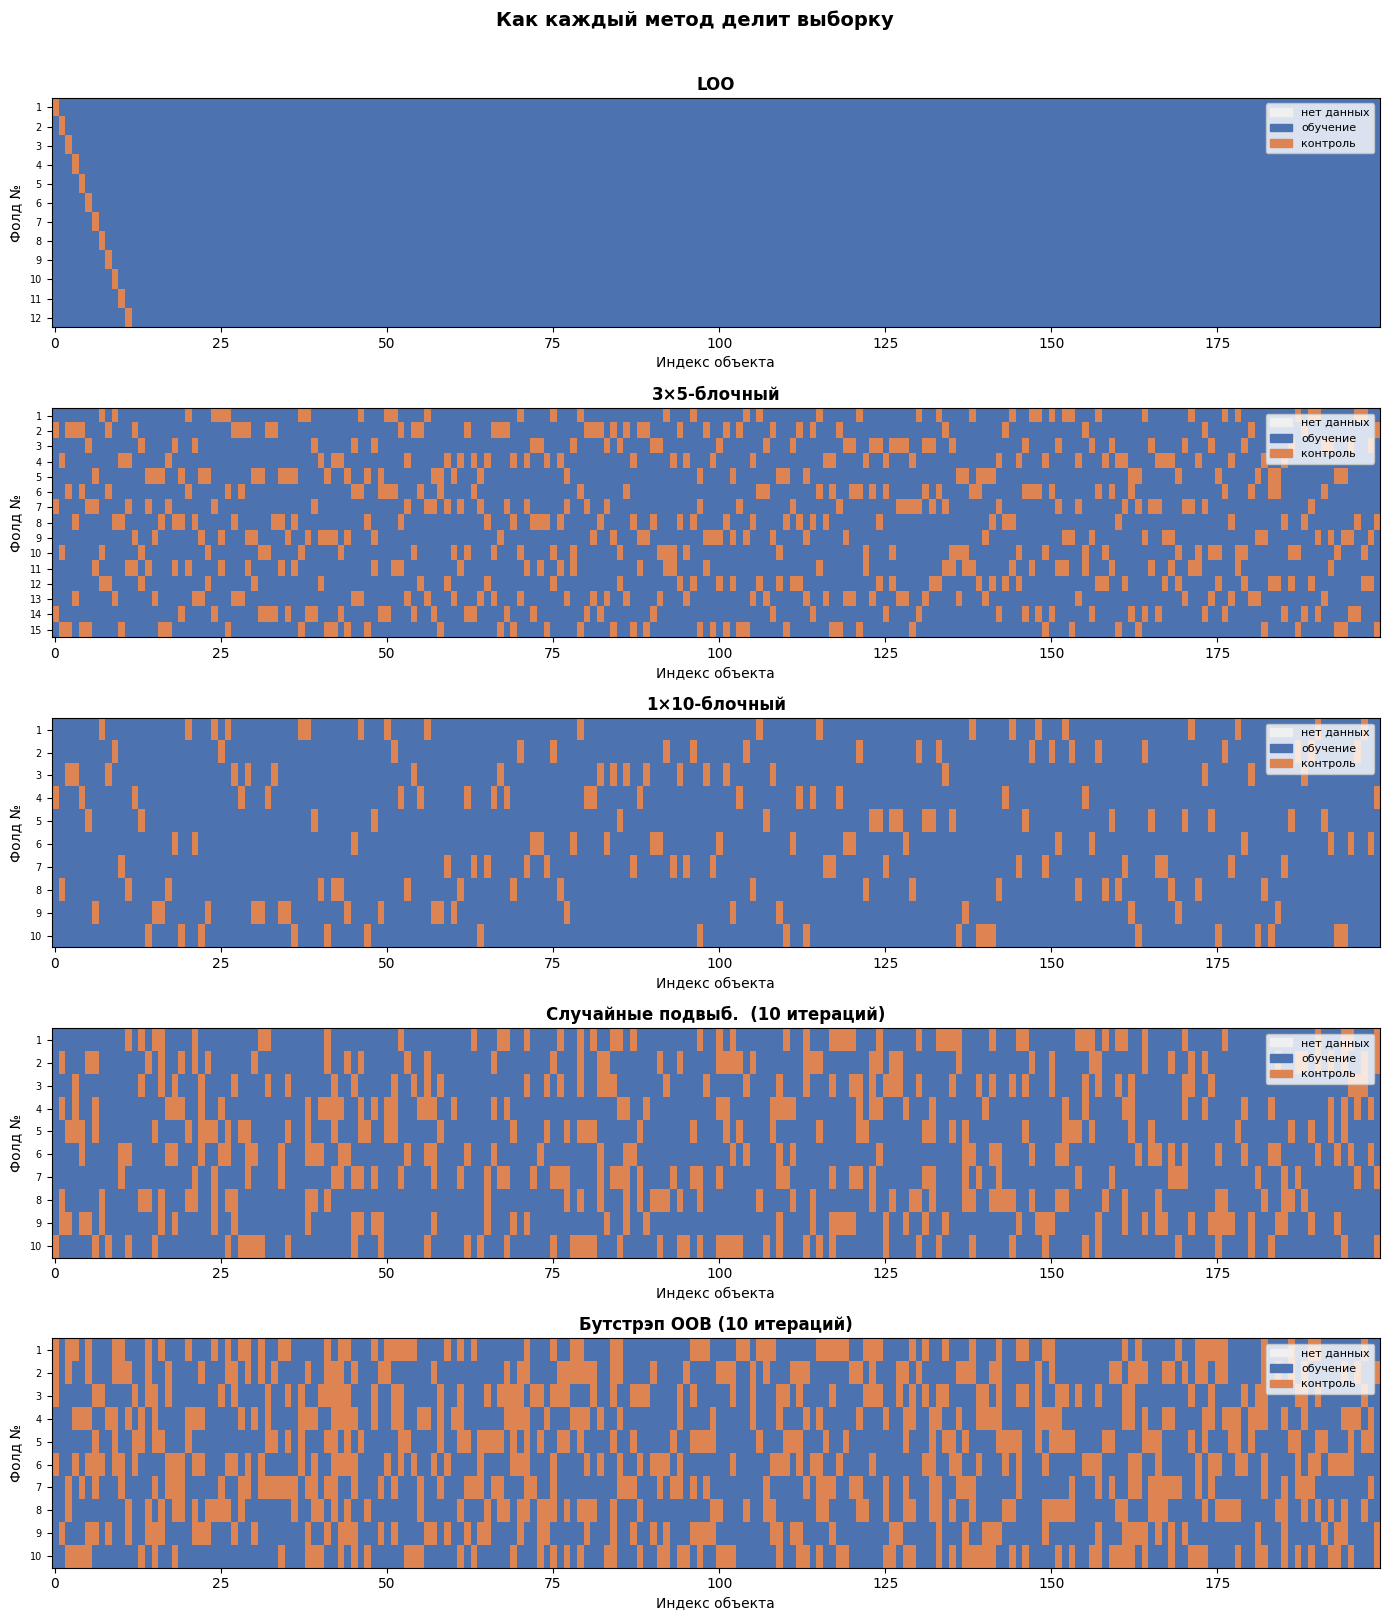

In [51]:
fig, axes = plt.subplots(
    len(splitters_to_show),
    1,
    figsize=(14, 3.2 * len(splitters_to_show))
)

for ax, (spl, title, max_f) in zip(axes, splitters_to_show):
    plot_splits(spl, X, title, max_folds=max_f, ax=ax)

plt.suptitle("Как каждый метод делит выборку", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

In [52]:
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
metric = MSE()

In [58]:
X_small = X[:50]
y_small = y[:50]
model_small = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

print("  FullCV (m=2, n=50)...")
full_result = CVRunner(
    model_small,
    FullCVSplitter(m=2, max_combinations=None),
    metric
).run(X_small, y_small, "FullCV (эталон)")
print(f"    → {full_result}")

print("  LOO (n=200)...")
loo_result = CVRunner(model, LOOSplitter(), metric).run(X, y, "LOO")
print(f"    → {loo_result}")

print("  10×5-блочный...")
kfold_result = CVRunner(
    model,
    RepeatedKFoldSplitter(repeat=10, k=5, random_seed=42),
    metric
).run(X, y, "10×5-блочный")
print(f"    → {kfold_result}")

print("  Случайные подвыборки...")
rs_result = CVRunner(
    model,
    RandomSubsampleSplitter(t=50, p=0.25, random_seed=42),
    metric
).run(X, y, "Случайные подвыб.")
print(f"    → {rs_result}")

print("  Бутстрэп...")
boot_result = CVRunner(
    model,
    BootstrapSplitter(t=50, random_seed=42),
    metric
).run(X, y, "Бутстрэп")
print(f"    → {boot_result}")
print(f"    .632 = {boot_result.score_632:.5f}")

  FullCV (m=2, n=50)...
    → CVResult(method='FullCV (эталон)', mean=0.69430, std=0.76286, n_folds=1225)
  LOO (n=200)...
    → CVResult(method='LOO', mean=0.48843, std=1.00532, n_folds=200)
  10×5-блочный...
    → CVResult(method='10×5-блочный', mean=0.52955, std=0.15590, n_folds=50)
  Случайные подвыборки...
    → CVResult(method='Случайные подвыб.', mean=0.53885, std=0.11167, n_folds=50)
  Бутстрэп...
    → BootstrapResult(method='Бутстрэп', oob_mean=0.58749, train=0.07388, 632=0.39848, n_folds=50)
    .632 = 0.39848


In [59]:
comparator = CVComparator(baseline=full_result)
comparator.add(loo_result).add(kfold_result).add(rs_result).add(boot_result)

table = comparator.table()
print("\n=== Сравнительная таблица ===")
print(table)


=== Сравнительная таблица ===
                  Metric      Mean       Std    Median    CI_low   CI_high  \
Method                                                                       
FullCV (эталон)      MSE  0.694297  0.762859  0.438942  0.651536  0.737059   
LOO                  MSE  0.488429  1.005322  0.140566  0.348249  0.628610   
10×5-блочный         MSE  0.529550  0.155899  0.507550  0.485245  0.573856   
Случайные подвыб.    MSE  0.538848  0.111667  0.525351  0.507113  0.570584   
Бутстрэп             MSE  0.587491  0.124642  0.570031  0.552068  0.622914   

                   N_folds  delta_baseline  Train_score  Score_.632  
Method                                                               
FullCV (эталон)       1225        0.000000          NaN         NaN  
LOO                    200       -0.205868          NaN         NaN  
10×5-блочный            50       -0.164747          NaN         NaN  
Случайные подвыб.       50       -0.155449          NaN         NaN  
Бу

C:\Users\venom\AppData\Local\Temp\ipykernel_12956\3262853412.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(names, rotation=15, ha="right")


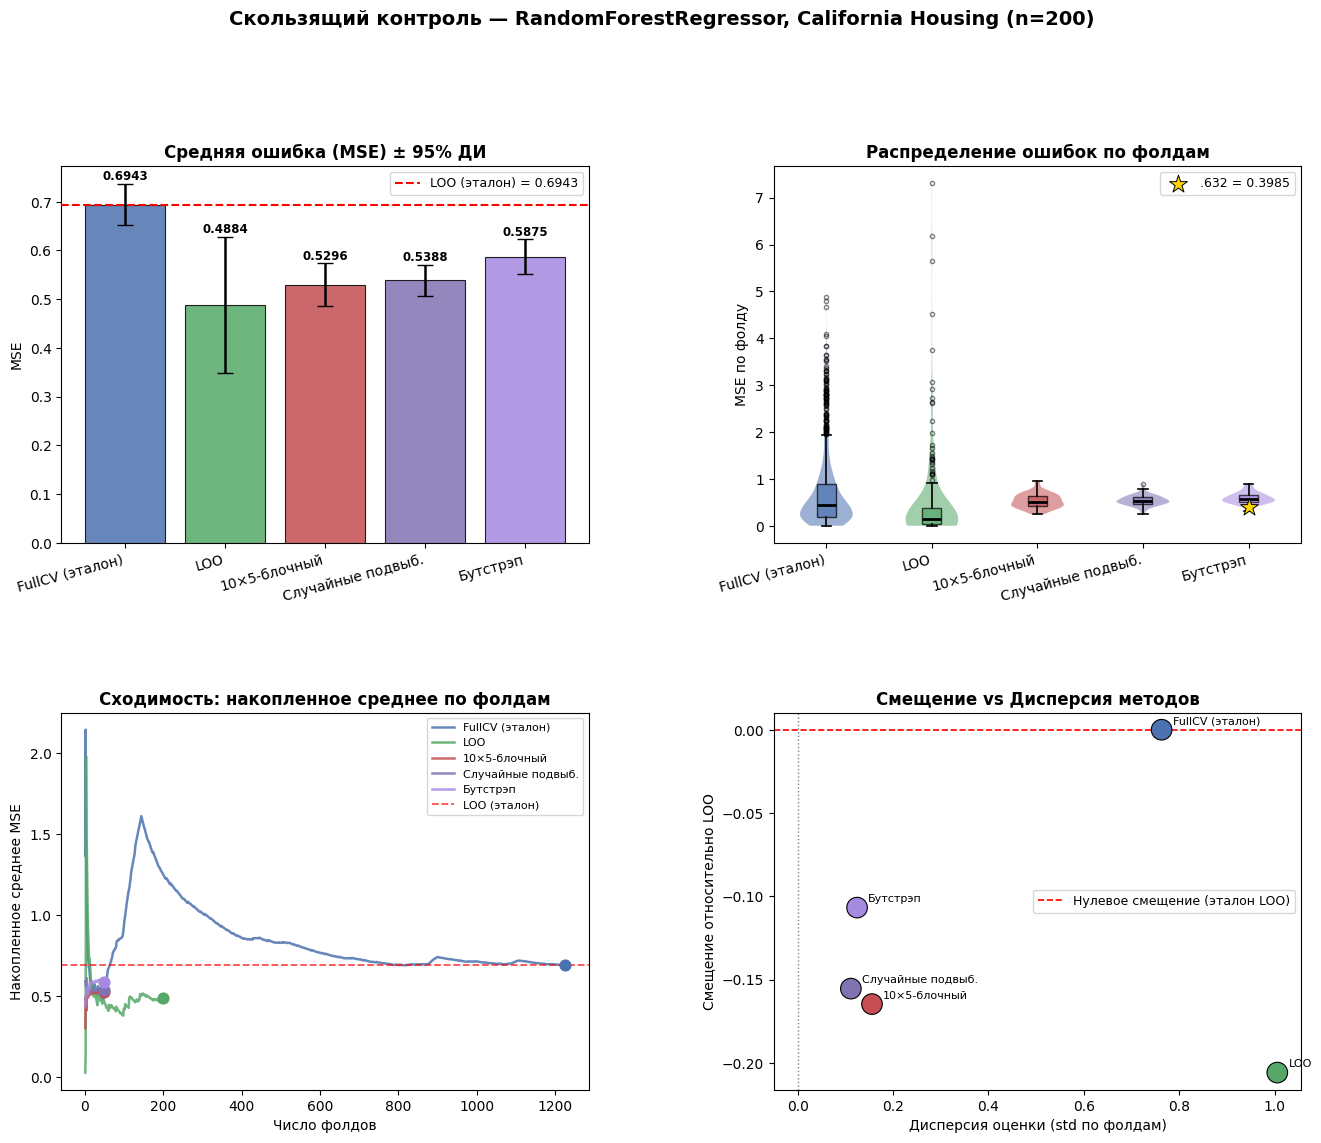

In [64]:
results_all = [full_result, loo_result, kfold_result, rs_result, boot_result]
names = [r.method_name for r in results_all]
means = [r.mean for r in results_all]
stds = [r.std for r in results_all]
COLORS = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#A689E1"]

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── График 1: Barplot mean ± CI ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

bars = ax1.bar(names, means, color=COLORS, alpha=0.85, edgecolor="black", linewidth=0.8, zorder=3)

for i, r in enumerate(results_all):
    ci_lo, ci_hi = r.confidence_interval(alpha=0.05)
    ax1.errorbar(
        i, r.mean,
        yerr=[[r.mean - ci_lo], [ci_hi - r.mean]],
        fmt="none", color="black", capsize=6, linewidth=1.8, zorder=4
    )
    ax1.text(i, r.mean + (ci_hi - r.mean) + 0.002,
             f"{r.mean:.4f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax1.axhline(full_result.mean, color="red", linestyle="--", linewidth=1.5,
            label=f"LOO (эталон) = {full_result.mean:.4f}", zorder=5)
ax1.set_title("Средняя ошибка (MSE) ± 95% ДИ", fontweight="bold")
ax1.set_ylabel("MSE")
ax1.set_xticklabels(names, rotation=15, ha="right")
ax1.legend(fontsize=9)

# ── График 2: Violin + boxplot fold scores ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

parts = ax2.violinplot(
    [r.fold_scores for r in results_all],
    positions=range(len(results_all)),
    showmedians=False, showextrema=False
)
for pc, color in zip(parts["bodies"], COLORS):
    pc.set_facecolor(color)
    pc.set_alpha(0.55)

bp = ax2.boxplot(
    [r.fold_scores for r in results_all],
    positions=range(len(results_all)),
    widths=0.18, patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=3, alpha=0.5),
)
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# .632 для бутстрэпа
for i, r in enumerate(results_all):
    if isinstance(r, BootstrapResult):
        ax2.scatter(i, r.score_632, marker="*", s=180, color="gold",
                    edgecolors="black", linewidth=0.7, zorder=5, label=f".632 = {r.score_632:.4f}")

ax2.set_title("Распределение ошибок по фолдам", fontweight="bold")
ax2.set_ylabel("MSE по фолду")
ax2.set_xticks(range(len(results_all)))
ax2.set_xticklabels(names, rotation=15, ha="right")
ax2.legend(fontsize=9)

# ── График 3: Сходимость скользящего контроля ────────────────────────────
#   Как изменяется cumulative mean по мере накопления фолдов
ax3 = fig.add_subplot(gs[1, 0])

for r, color in zip(results_all, COLORS):
    cumulative_mean = np.cumsum(r.fold_scores) / np.arange(1, len(r.fold_scores) + 1)
    ax3.plot(range(1, len(cumulative_mean) + 1), cumulative_mean,
             color=color, linewidth=1.8, label=r.method_name, alpha=0.85)
    ax3.scatter(len(cumulative_mean), cumulative_mean[-1],
                color=color, s=60, zorder=5)

ax3.axhline(full_result.mean, color="red", linestyle="--", linewidth=1.3,
            alpha=0.7, label=f"LOO (эталон)")
ax3.set_title("Сходимость: накопленное среднее по фолдам", fontweight="bold")
ax3.set_xlabel("Число фолдов")
ax3.set_ylabel("Накопленное среднее MSE")
ax3.legend(fontsize=8)

# ── График 4: Смещение и дисперсия относительно эталона ──────────────────
ax4 = fig.add_subplot(gs[1, 1])

baseline = full_result.mean
bias = [r.mean - baseline for r in results_all]
variance = [r.std for r in results_all]

scatter = ax4.scatter(
    variance, bias,
    c=COLORS, s=220, edgecolors="black", linewidth=0.8, zorder=5
)

for i, (r, b, v) in enumerate(zip(results_all, bias, variance)):
    ax4.annotate(
        r.method_name,
        xy=(v, b), xytext=(8, 4),
        textcoords="offset points", fontsize=8,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.8)
    )

ax4.axhline(0, color="red", linestyle="--", linewidth=1.2,
            label="Нулевое смещение (эталон LOO)")
ax4.axvline(0, color="gray", linestyle=":", linewidth=1)

ax4.set_title("Смещение vs Дисперсия методов", fontweight="bold")
ax4.set_xlabel("Дисперсия оценки (std по фолдам)")
ax4.set_ylabel("Смещение относительно LOO")
ax4.legend(fontsize=9)

plt.suptitle(
    "Скользящий контроль — RandomForestRegressor, California Housing (n=200)",
    fontsize=14, fontweight="bold", y=1.01
)

plt.show()

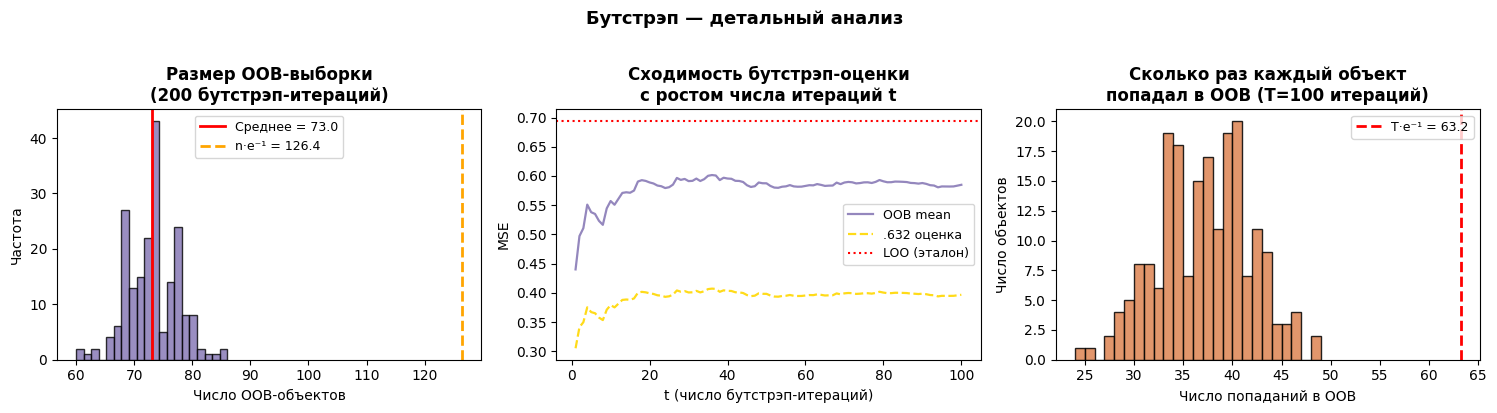

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ─ 7a: OOB-размер по итерациям ─────────────────────────────────────────
n = len(X)
rng = np.random.RandomState(42)
oob_sizes = []
for _ in range(200):
    boot_idx = rng.choice(n, size=n, replace=True)
    oob_sizes.append(n - len(np.unique(boot_idx)))

ax = axes[0]
ax.hist(oob_sizes, bins=20, color="#8172B2", edgecolor="black", alpha=0.8)
ax.axvline(np.mean(oob_sizes), color="red", linewidth=2,
           label=f"Среднее = {np.mean(oob_sizes):.1f}")
ax.axvline(n * (1 - 1 / np.e), color="orange", linestyle="--", linewidth=2,
           label=f"n·e⁻¹ = {n * (1 - 1 / np.e):.1f}")
ax.set_title("Размер OOB-выборки\n(200 бутстрэп-итераций)", fontweight="bold")
ax.set_xlabel("Число OOB-объектов")
ax.set_ylabel("Частота")
ax.legend(fontsize=9)

# ─ 7b: Сходимость .632 с числом итераций ───────────────────────────────
ax = axes[1]
t_values = range(1, 101)
oob_means, oob_632s = [], []

boot_runner_scores = []
for t in t_values:
    r = CVRunner(
        model,
        BootstrapSplitter(t=t, random_seed=42),
        metric
    ).run(X, y, "boot")
    oob_means.append(r.mean)
    oob_632s.append(r.score_632 if isinstance(r, BootstrapResult) else r.mean)

ax.plot(t_values, oob_means, color="#8172B2", linewidth=1.6,
        label="OOB mean", alpha=0.85)
ax.plot(t_values, oob_632s, color="gold", linewidth=1.6,
        linestyle="--", label=".632 оценка", alpha=0.9)
ax.axhline(full_result.mean, color="red", linestyle=":", linewidth=1.5,
           label=f"LOO (эталон)")
ax.set_title("Сходимость бутстрэп-оценки\nс ростом числа итераций t", fontweight="bold")
ax.set_xlabel("t (число бутстрэп-итераций)")
ax.set_ylabel("MSE")
ax.legend(fontsize=9)

# ─ 7c: Частота попадания в OOB ─────────────────────────────────────────
ax = axes[2]
T = 100
hit_count = np.zeros(n, dtype=int)  # сколько раз объект попал в OOB
rng = np.random.RandomState(42)
for _ in range(T):
    boot_idx = rng.choice(n, size=n, replace=True)
    oob = np.setdiff1d(np.arange(n), boot_idx)
    hit_count[oob] += 1

ax.hist(hit_count, bins=25, color="#DD8452", edgecolor="black", alpha=0.85)
ax.axvline(T * (1 - 1 / np.e), color="red", linewidth=2, linestyle="--",
           label=f"T·e⁻¹ = {T * (1 - 1 / np.e):.1f}")
ax.set_title(f"Сколько раз каждый объект\nпопадал в OOB (T={T} итераций)", fontweight="bold")
ax.set_xlabel("Число попаданий в OOB")
ax.set_ylabel("Число объектов")
ax.legend(fontsize=9)

plt.suptitle("Бутстрэп — детальный анализ", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()